# PyPulseq-Star spoiled GRE: a relationship-aware development workflow

This notebook introduces the six-stage PyPulseq-Star workflow used in the accompanying SoftwareX figure:

1. **Protocol definition**
2. **Relationship-aware symbolic layer**
3. **Sequence construction**
4. **Resolution and validation**
5. **Plots and inspection**
6. **Multi-backend export**

The example follows `examples/demo_GRE.py` and retains a single symbolic GRE kernel that is repeated through a logical phase-encoding loop. The same sequence definition is resolved for plotting and Pulseq export and is also lowered to a gammaSTAR `.seq.json` document.

### Learning goals

By the end of the notebook, a first-time developer should be able to:

- define scanner limits and a named GRE protocol;
- express phase-encoding and RF/ADC spoiling relationships;
- construct a compact node-based timeline;
- resolve symbolic quantities and validate timing;
- inspect waveforms and the relationship graph;
- export Pulseq and gammaSTAR representations.

> **Recommended use:** run the notebook section by section. Each section prints or plots a short confirmation so that the effect of the code remains visible during a talk or workshop.


## Setup




In [12]:
# Install the exact PyPulseq-Star release used in the SoftwareX manuscript
%pip install -q "pypulseq-star==0.2.0a1"

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import pypulseq_star as ppstar
from pypulseq_star.sequence import vary
from pypulseq_star.writers import GammaStarWriter, PulseqWriter

print(f"Imported pypulseq_star version: {ppstar.__version__}")
print(
    "Notebook workflow: protocol → relationships → compact timeline → "
    "resolution → inspection → export"
)

Imported pypulseq_star version: 0.2.0a1
Notebook workflow: protocol → relationships → compact timeline → resolution → inspection → export


# 1. Protocol definition

PyPulseq-Star separates **what the user intends to prescribe** from the event-level sequence implementation. The protocol contains named, editable parameters, while `Opts` defines scanner hardware and raster limits.

This first section intentionally defines only the direct user inputs. Derived quantities such as the phase-encode start and step are added in Section 2.


In [14]:
ORIENTATION = "sagittal"  # Try "axial" or "coronal" later.

system = ppstar.Opts(
    max_grad=28,
    grad_unit="mT/m",
    max_slew=150,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    rf_raster_time=2e-6,
    grad_raster_time=10e-6,
)

protocol = ppstar.Protocol(
    name="gre",
    description="Protocol-centered spoiled gradient-echo sequence.",
    parameters={
        "sequence_name": "gre",
        "sequence_type": "GRE",
        "orientation": ORIENTATION,
        "fov": 256e-3,
        "n_x": 64,
        "n_y": 64,
        "slice_thickness": 3e-3,
        "flip_angle": 10.0,
        "rf_duration": 3e-3,
        "readout_duration": 3.2e-3,
        "echo_time": 5e-3,
        "repetition_time": 12e-3,
        "apodization": 0.42,
        "time_bw_product": 4.0,
        "rf_spoiling_increment": 117.0,
        "prephaser_duration": 1e-3,
        "rf_phase_offset": 0.0,
        "rf_frequency_offset": 0.0,
        "adc_phase_offset": 0.0,
        "adc_frequency_offset": 0.0,
    },
    aliases={
        "Name": "sequence_name",
        "TE": "echo_time",
        "TR": "repetition_time",
        "Orientation": "orientation",
        "rf_spoiling_inc": "rf_spoiling_increment",
        "phase_encode_start": "phase_encode_start",
        "phase_encode_step": "phase_encode_step",
    },
)

print("System limits")
print(f"  max gradient: {system.max_grad:.3g} Hz/m")
print(f"  max slew:     {system.max_slew:.3g} Hz/m/s")
print(f"  grad raster:  {system.grad_raster_time * 1e6:.1f} µs")
print()

print("Selected GRE protocol")
for key in (
    "orientation", "fov", "n_x", "n_y", "slice_thickness",
    "flip_angle", "echo_time", "repetition_time",
    "rf_spoiling_increment",
):
    value = protocol.get_parameter(key)
    if key in {"fov", "slice_thickness"}:
        shown = f"{value * 1e3:.3f} mm"
    elif key in {"echo_time", "repetition_time"}:
        shown = f"{value * 1e3:.3f} ms"
    elif key == "flip_angle":
        shown = f"{value:.1f}°"
    else:
        shown = value
    print(f"  {key:24s}: {shown}")


System limits
  max gradient: 1.19e+06 Hz/m
  max slew:     6.39e+09 Hz/m/s
  grad raster:  10.0 µs

Selected GRE protocol
  orientation             : sagittal
  fov                     : 256.000 mm
  n_x                     : 64
  n_y                     : 64
  slice_thickness         : 3.000 mm
  flip_angle              : 10.0°
  echo_time               : 5.000 ms
  repetition_time         : 12.000 ms
  rf_spoiling_increment   : 117.0


# 2. Relationship-aware symbolic layer

The protocol parameters become symbolic references through `protocol.symbols`. Derived quantities are stored as expressions rather than immediately converted into fixed numbers.

For this GRE example, the principal tested relationships are:

- phase-encode start depends on `n_y` and `fov`;
- phase-encode step depends on `fov`;
- loop length depends on `n_y`;
- phase-encode gradient area varies across the `ky_index` loop;
- RF and ADC phase offsets vary together according to `rf_spoiling_increment`;
- TE and TR control symbolic delay fills;
- orientation controls the logical-to-physical encoding frame.


Stored symbolic protocol relationships
  phase_encode_start = BinaryExpression(((-0.5 * n_y) / fov))
  phase_encode_step  = BinaryExpression((1.0 / fov))

Interpretation at the current protocol defaults
  loop length:        64 phase encodes
  phase-encode start: -125 1/m
  phase-encode step:  3.90625 1/m
  final ky value:     121.094 1/m


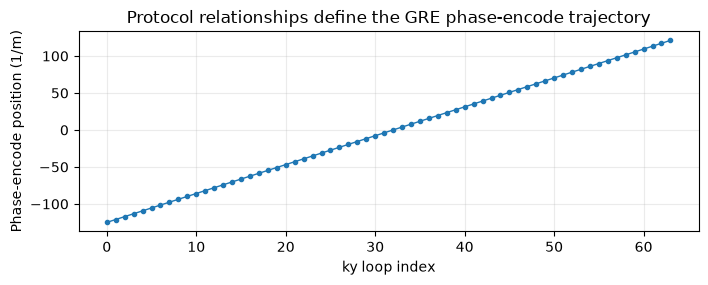

In [15]:
p = protocol.symbols

# Even-matrix DFT convention:
# ky(i) = -0.5 * n_y / fov + i / fov, i = 0 ... n_y - 1
protocol.parameters["phase_encode_start"] = -0.5 * p.n_y / p.fov
protocol.parameters["phase_encode_step"] = 1.0 / p.fov

print("Stored symbolic protocol relationships")
print(f"  phase_encode_start = {protocol.parameters['phase_encode_start']}")
print(f"  phase_encode_step  = {protocol.parameters['phase_encode_step']}")
print()

# A compact numerical interpretation of the same relationships.
n_y = protocol.get_parameter("n_y")
fov = protocol.get_parameter("fov")
phase_encode_start = -0.5 * n_y / fov
phase_encode_step = 1.0 / fov
ky = phase_encode_start + np.arange(n_y) * phase_encode_step

print("Interpretation at the current protocol defaults")
print(f"  loop length:        {n_y} phase encodes")
print(f"  phase-encode start: {phase_encode_start:.6g} 1/m")
print(f"  phase-encode step:  {phase_encode_step:.6g} 1/m")
print(f"  final ky value:     {ky[-1]:.6g} 1/m")

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(np.arange(n_y), ky, marker=".", linewidth=1)
ax.set_xlabel("ky loop index")
ax.set_ylabel("Phase-encode position (1/m)")
ax.set_title("Protocol relationships define the GRE phase-encode trajectory")
ax.grid(True, alpha=0.25)
plt.show()


# 3. Sequence construction

The sequence stores **one representative GRE kernel** and attaches a logical `n_y` repetition loop. This keeps the symbolic timeline compact while allowing writers to materialize or preserve the loop according to the target backend.

The event constructors remain familiar to PyPulseq users, while node paths, roles, logical axes, and `vary(...)` declarations retain additional semantic information.


In [16]:
seq = ppstar.Sequence(
    system=system,
    protocol=protocol,
    name=p.sequence_name,
)

seq.set_encoding_frame(ORIENTATION)
seq.set_definition("FOV", [p.fov, p.fov, p.slice_thickness])
seq.set_definition("Name", p.sequence_name)

kernel = seq.set_node(
    "kernel",
    role="kernel",
    factor=p.n_y,
    repeat_every=p.repetition_time,
    counter="ky_index",
    repeat_mode="loop",
)

delta_k = p.phase_encode_step

# RF excitation and slice-select / rephasing gradients
rf, gz, gz_reph = ppstar.make_sinc_pulse(
    flip_angle=p.flip_angle * math.pi / 180.0,
    duration=p.rf_duration,
    slice_thickness=p.slice_thickness,
    apodization=p.apodization,
    time_bw_product=p.time_bw_product,
    phase_offset=p.rf_phase_offset,
    freq_offset=p.rf_frequency_offset,
    system=system,
    return_gz=True,
    delay=system.rf_dead_time,
    use="excitation",
    name="rf_excitation",
    gz_name="gz_slice_select",
    gzr_name="gz_rephaser",
)
gz.axis_role = "slice"
gz_reph.axis_role = "slice"

# Readout and ADC
gx = ppstar.make_trapezoid(
    channel="x",
    axis_role="read",
    flat_area=p.n_x * delta_k,
    flat_time=p.readout_duration,
    system=system,
    name="gx_readout",
    role="readout",
)
adc = ppstar.make_adc(
    num_samples=p.n_x,
    duration=p.readout_duration,
    delay=system.adc_dead_time,
    phase_offset=p.adc_phase_offset,
    freq_offset=p.adc_frequency_offset,
    system=system,
    name="adc_readout",
    role="acquisition",
)

# Prephasing
gx_pre = ppstar.make_trapezoid(
    channel="x",
    axis_role="read",
    area=-0.5 * gx.area,
    duration=p.prephaser_duration,
    system=system,
    name="gx_prephaser",
    role="prephasing",
)
gy_pre = ppstar.make_trapezoid(
    channel="y",
    axis_role="phase",
    area=1.0,
    duration=p.prephaser_duration,
    system=system,
    name="gy_phase_encode",
    role="phase_encode",
)

# Declarative variation across the logical ky loop
kernel.vary(
    vary(
        gy_pre,
        "area",
        strength=p.phase_encode_start,
        step=p.phase_encode_step,
    ),
    vary(
        [rf, adc],
        "phase_offset",
        strength=0.0,
        step=p.rf_spoiling_increment * math.pi / 180.0,
        mode="accumulated",
        wrap=2.0 * math.pi,
    ),
)

# Gradient spoiling
gx_spoil = ppstar.make_trapezoid(
    channel="x",
    axis_role="read",
    area=2.0 * p.n_x * delta_k,
    system=system,
    name="gx_spoil",
    role="spoiling",
)
gy_spoil = ppstar.make_trapezoid(
    channel="y",
    axis_role="phase",
    area=2.0 * p.n_y * delta_k,
    duration=seq.duration(gx_spoil),
    system=system,
    name="gy_spoil",
    role="spoiling",
)
gz_spoil = ppstar.make_trapezoid(
    channel="z",
    axis_role="slice",
    area=4.0 / p.slice_thickness,
    system=system,
    name="gz_spoil",
    role="spoiling",
)

# Symbolic TE fill: RF center → ADC center
excitation_tail = seq.duration([rf, gz]) - rf.anchor("center")
prephase_occupancy = seq.duration([gx_pre, gy_pre, gz_reph])
readout_to_echo = adc.anchor("center")
te_fixed_occupancy = excitation_tail + prephase_occupancy + readout_to_echo
te_fill_duration = p.echo_time - te_fixed_occupancy
te_fill = ppstar.make_delay(
    te_fill_duration,
    system=system,
    name="te_fill",
    role="echo_time_fill",
)

# Compact GRE kernel blocks
seq.add_block(rf, gz, name="excitation", role="excitation",
              node="kernel.excitation")
seq.add_block(gx_pre, gy_pre, gz_reph, name="prephase", role="prephase",
              node="kernel.prephase")
seq.add_block(te_fill, name="echo_delay", role="echo_time_fill",
              node="kernel.echo_delay")
seq.add_block(gx, adc, name="readout", role="readout",
              node="kernel.readout")
seq.add_block(gx_spoil, gy_spoil, gz_spoil, name="spoiling",
              role="spoiling", node="kernel.spoiling")

# Symbolic TR fill: complete occupied kernel → requested TR
kernel_occupancy = seq.duration(
    start_block_name="excitation",
    end_block_name="spoiling",
)
tr_fill_duration = p.repetition_time - kernel_occupancy
tr_fill = ppstar.make_delay(
    tr_fill_duration,
    system=system,
    name="tr_fill",
    role="repetition_time_fill",
)
seq.add_block(tr_fill, name="repetition_delay",
              role="repetition_time_fill",
              node="kernel.repetition_delay")

kernel_record = seq.nodes["kernel"]
print("Compact timeline created")
print(f"  stored kernel blocks: {len(seq.timeline.blocks)}")
print(f"  repeat mode:          {kernel_record['repeat_mode']}")
print(f"  loop counter:         {kernel_record['counter']}")
print(f"  loop factor:          {kernel_record['repeat_count']}")
print(f"  declared variations:  {len(kernel_record.get('variations', []))}")
print()
print("Encoding frame")
print(f"  read direction:  {seq.encoding_frame.read_dir}")
print(f"  phase direction: {seq.encoding_frame.phase_dir}")
print(f"  slice direction: {seq.encoding_frame.slice_dir}")


Compact timeline created
  stored kernel blocks: 6
  repeat mode:          loop
  loop counter:         ky_index
  loop factor:          ParameterRef(n_y)
  declared variations:  2

Encoding frame
  read direction:  (0.0, 1.0, 0.0)
  phase direction: (0.0, 0.0, 1.0)
  slice direction: (1.0, 0.0, 0.0)


# 4. Resolution and validation

`seq.resolve()` evaluates symbolic protocol values, timing fills, node repetition metadata, and event properties into an immutable numeric realization. Validation then checks timing and hardware feasibility.

This is the boundary between the editable symbolic model and backend-ready numerical data.


In [17]:
print("Requested symbolic fills")
print(f"  TE fill: {te_fill_duration.eval(seq) * 1e3:.3f} ms")
print(f"  TR fill: {tr_fill_duration.eval(seq) * 1e3:.3f} ms")

resolved = seq.resolve()
timing_ok, timing_report = resolved.check_timing()

print()
print("Resolved protocol and timing")
print(f"  timing check:         {'PASS' if timing_ok else 'FAIL'}")
print(f"  TE:                   {resolved.protocol.echo_time * 1e3:.3f} ms")
print(f"  TR:                   {resolved.protocol.repetition_time * 1e3:.3f} ms")
print(f"  phase encodes:        {resolved.protocol.n_y}")
print(f"  phase-encode start:   {resolved.protocol.phase_encode_start:.6g} 1/m")
print(f"  phase-encode step:    {resolved.protocol.phase_encode_step:.6g} 1/m")
print(f"  resolved TE fill:     {te_fill_duration.eval(resolved) * 1e3:.3f} ms")
print(f"  resolved TR fill:     {tr_fill_duration.eval(resolved) * 1e3:.3f} ms")
print(f"  resolved kernel time: {resolved.node('kernel').duration * 1e3:.3f} ms")

if timing_report:
    print("\nTiming diagnostics")
    for item in timing_report:
        print(f"  - {item}")
else:
    print("\nNo timing violations were reported.")


Requested symbolic fills
  TE fill: 0.650 ms
  TR fill: 3.210 ms

Resolved protocol and timing
  timing check:         PASS
  TE:                   5.000 ms
  TR:                   12.000 ms
  phase encodes:        64
  phase-encode start:   -125 1/m
  phase-encode step:    3.90625 1/m
  resolved TE fill:     0.650 ms
  resolved TR fill:     2.560 ms
  resolved kernel time: 12.000 ms

No timing violations were reported.


# 5. Plots and inspection

This section provides two complementary views:

1. the **one-TR waveform plot**, showing the resolved RF, ADC, and physical gradient channels;
2. the interactive **Streamlit relationship dashboard**, which opens in a browser and displays protocol, hierarchy, and relationship information from an exported graph JSON specification.

For the sagittal orientation used here, logical read, phase, and slice directions are mapped to physical scanner axes by the active encoding frame.


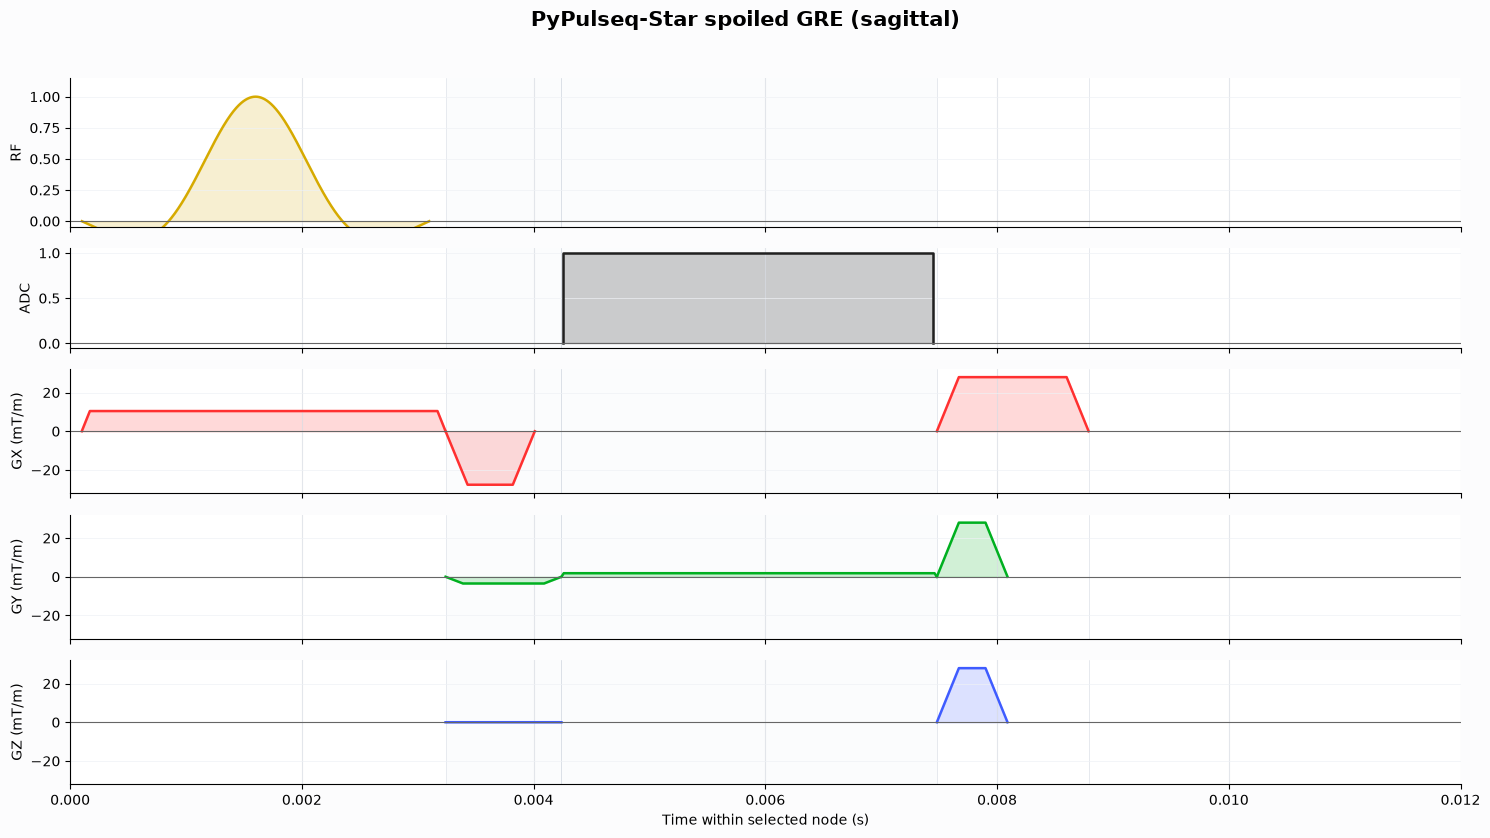

Displayed one resolved GRE repetition.


In [18]:
# Assign the returned Matplotlib figure to a variable.
# seq.plot() already calls plt.show(); leaving the returned figure as the
# final expression in a notebook cell causes Jupyter to display it a second time.
waveform_figure = seq.plot(
    realization=resolved,
    one_tr=True,
    title=f"PyPulseq-Star spoiled GRE ({ORIENTATION})",
    gradient_scale="mt_per_m",
    figsize=(15, 8.5),
    dpi=140,
)

print("Displayed one resolved GRE repetition.")


In [19]:
import sys

from apps.relationship_graph_spec import (
    relationship_dashboard_command,
    write_relationship_dashboard_json,
)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root containing src/apps/relationship_graph_viewer.py."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src/apps/relationship_graph_viewer.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the PyPulseq-Star repository root. "
        "Open the notebook from within the cloned repository."
    )


project_root = find_project_root()
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))



graph_json_path = write_relationship_dashboard_json(
    seq,
    project_root / "out/gre/gre.relationship_graph.json",
    title="PyPulseq-Star spoiled GRE relationship graph",
    include_protocol=True,
    include_system=True,
    include_relationships=True,
    include_derived=False,
    show_all_protocol_parameters=False,
)

dashboard_command = relationship_dashboard_command(graph_json_path)

print(f"Wrote relationship graph JSON:\n  {graph_json_path}")
print("\nLaunch the interactive dashboard from the repository root:")
print(dashboard_command)


Wrote relationship graph JSON:
  /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/out/gre/gre.relationship_graph.json

Launch the interactive dashboard from the repository root:
cd /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean && /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/.venv/bin/python -m streamlit run /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/src/apps/relationship_graph_viewer.py -- --graph /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/out/gre/gre.relationship_graph.json


In [20]:
# Run this cell to launch the interactive Streamlit dashboard.
# Streamlit opens the relationship viewer in a browser tab. The process remains
# active until stopped from the terminal or interrupted.

from apps.relationship_graph_spec import launch_relationship_dashboard

relationship_dashboard_process = launch_relationship_dashboard(
    graph_json_path,
    wait=False,
)

print("Relationship dashboard launched.")
print("Stop it later with Ctrl+C in its terminal, or terminate the process with:")
print("  relationship_dashboard_process.terminate()")


[dashboard] launching:
    /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/.venv/bin/python -m streamlit run /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/src/apps/relationship_graph_viewer.py -- --graph /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/out/gre/gre.relationship_graph.json
[dashboard] cwd: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean
Relationship dashboard launched.
Stop it later with Ctrl+C in its terminal, or terminate the process with:
  relationship_dashboard_process.terminate()


/Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/.venv/bin/python: No module named streamlit


# 6. Multi-backend export

The same symbolic sequence is lowered into:

- a Pulseq `.seq` file using the resolved realization;
- a gammaSTAR `.seq.json` document using the symbolic sequence plus validated defaults.

The output directory below is local to the repository and can later be adapted for Colab downloads.


In [21]:
output_dir = Path("out/notebook_gre")
output_dir.mkdir(parents=True, exist_ok=True)

seq_path = PulseqWriter(seq).write(
    output_dir / f"gre_{ORIENTATION}.seq",
    realization=resolved,
)
json_path = GammaStarWriter(seq).write(
    output_dir / f"gre_{ORIENTATION}.seq.json",
    defaults=resolved,
)

print("Export complete")
print(f"  Pulseq:    {seq_path} ({seq_path.stat().st_size / 1024:.1f} KiB)")
print(f"  gammaSTAR: {json_path} ({json_path.stat().st_size / 1024:.1f} KiB)")


Export complete
  Pulseq:    out/notebook_gre/gre_sagittal.seq (12.9 KiB)
  gammaSTAR: out/notebook_gre/gre_sagittal.seq.json (226.5 KiB)


In [11]:
with json_path.open("r", encoding="utf-8") as handle:
    gamma_doc = json.load(handle)

parameter_keys = gamma_doc.get("parameters", {}).keys()

print("Cross-representation confirmation")
print(f"  gammaSTAR document name: {gamma_doc.get('name')}")
print(f"  total parameter scripts: {len(list(parameter_keys))}")
print("  loop metadata present:   ",
      "root.kernel.length" in gamma_doc.get("parameters", {}))
print("  protocol FOV present:    ",
      any(key.startswith("root.prot.fov") for key in parameter_keys))
print("  RF spoiling relationship:",
      any("rf_spoiling_increment" in key for key in parameter_keys))

print("\nThe two files were generated from the same symbolic sequence object.")


Cross-representation confirmation
  gammaSTAR document name: gre
  total parameter scripts: 574
  loop metadata present:    True
  protocol FOV present:     True
  RF spoiling relationship: True

The two files were generated from the same symbolic sequence object.


## Suggested first modifications

Run one change at a time and repeat Sections 4–6:

- change `n_y` from `64` to `128` and confirm the loop length and phase-encode start;
- change `fov` from `0.256` m to `0.128` m and inspect phase-encode scaling;
- change `rf_spoiling_increment` and inspect the exported RF/ADC phase relationships;
- change TE or TR and confirm the resolved fills;
- switch among axial, coronal, and sagittal orientations and inspect physical gradient axes;
- compare the default and edited `.seq` and `.seq.json` exports.

These exercises correspond directly to the GRE acceptance tests used for the SoftwareX release.
